# Computer Exercise 2.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.3 Tridiagonal and Banded Systems
> **풀이 일자**: Day 10
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Consider the one-dimensional Poisson boundary-value problem
> $$ -u''(x) = f(x), \quad x \in (0,1), \qquad u(0) = \alpha,\;\; u(1) = \beta. $$
> Discretise on a uniform grid $x_i = i h$, $h = 1/(n+1)$, $i = 0,\ldots,n+1$ using the standard
> second-order central difference
> $$ -\frac{u_{i-1} - 2 u_i + u_{i+1}}{h^2} = f(x_i), \quad i = 1,\ldots,n. $$
> Build the resulting **tridiagonal** linear system and solve it with the Thomas algorithm from Problem 1.
> Pick a manufactured solution $u^\*(x) = \sin(\pi x) + \alpha (1-x) + \beta x$ so that $f$ and the
> boundary values are known exactly. Report the discrete **max-norm error**
> $E(h) = \max_i |u_i - u^\*(x_i)|$ for $n = 2^k - 1$, $k = 3,\ldots,12$, and verify the expected
> **second-order convergence** $E(h) = \mathcal{O}(h^2)$.

### 한국어 풀이용 정리

1번에서 만든 Thomas 알고리즘에 *실제 PDE* 를 먹인다. 1D Poisson 방정식의 가장 단순한 형태에
2차 중심차분을 적용하면 $A$ 가 정확히 **tridiagonal** 이 되고, 행렬은 *strict diagonal dominance* 가 아닌
**대칭 양정치(SPD)** — Thomas 가 그대로 안정적으로 동작한다.

**제조해(manufactured solution)** 로 $u^\*(x) = \sin(\pi x) + \alpha(1-x) + \beta x$ 를 잡으면
$f = \pi^2 \sin(\pi x)$, 경계값도 $\alpha, \beta$. 격자 간격 $h$ 를 절반으로 줄여 가면서
오차가 **$h^2$ 비율로** 줄어드는지 확인한다.


## 2. 수학적 배경

### 2.1 유한차분 행렬

격자 $x_i = ih$, $h = 1/(n+1)$, 내부 점 $i = 1, \ldots, n$ 에서 미지수 $u_i$. 양 끝은 디리클레로
고정 — $u_0 = \alpha$, $u_{n+1} = \beta$. 중심차분을 정리하면

$$
\frac{1}{h^2}\,(-u_{i-1} + 2 u_i - u_{i+1}) = f_i, \qquad i = 1, \ldots, n.
$$

이를 행렬-벡터로 쓰면 $A \mathbf{u} = \mathbf{d}$, 여기서

$$
A = \frac{1}{h^2}
\begin{pmatrix}
 2 & -1 &        &    \\
-1 &  2 & -1     &    \\
   & \ddots & \ddots & \ddots\\
   &        & -1 & 2
\end{pmatrix},
\qquad
d_i = f_i + \begin{cases} \alpha/h^2 & i=1\\ \beta/h^2 & i=n \\ 0 & \text{else}\end{cases}
$$

(경계값이 우변으로 흡수된다.)

### 2.2 $A$ 의 성질

* **대칭 양정치**: 고유값 $\lambda_k = \frac{2}{h^2}(1 - \cos(k\pi h))$, $k = 1, \ldots, n$, 모두 양수.
* **3중대각**: Thomas 가 그대로 적용된다 — strict diagonal dominance 가 아니지만 SPD 라 안전.
* **조건수**: $\kappa(A) = \lambda_{\max}/\lambda_{\min} = \mathcal{O}(h^{-2}) = \mathcal{O}(n^2)$.

### 2.3 오차 분석

테일러 전개로

$$
-\frac{u^*(x_{i-1}) - 2 u^*(x_i) + u^*(x_{i+1})}{h^2}
= -u^{*\prime\prime}(x_i) - \frac{h^2}{12}\, u^{*(4)}(\xi_i),
$$

즉 *국소 절단오차* 는 $\tau_i = -\frac{h^2}{12} u^{*(4)}(\xi_i) = \mathcal{O}(h^2)$.

선형 시스템에서 $A (\mathbf{u}^* - \mathbf{u}) = \boldsymbol\tau$ 이고 $\|A^{-1}\|_\infty$ 가 유한하므로

$$
\boxed{\;\|\mathbf{u}^* - \mathbf{u}\|_\infty \;\le\; C\, h^2\;}
$$

— 격자를 절반으로 줄이면 오차는 **1/4** 로 줄어드는 *2차 수렴* 이다.

### 2.4 조건수의 영향

$\kappa(A) = \mathcal{O}(n^2)$ 이므로 *수치적인* 오차 한계는

$$
\|\mathbf{u}_{\text{computed}} - \mathbf{u}\|_\infty \approx \kappa(A) \cdot \varepsilon_{\text{mach}}
= \mathcal{O}(n^2 \cdot 10^{-16}).
$$

$n \approx 10^7$ 까지는 절단오차가 지배적이고 그 이상에서는 반올림오차가 절단오차를 추월한다.


## 3. 풀이 흐름

1. Day10 의 `thomas(a, b, c, d)` 를 재사용. (이 노트북 안에 그대로 inline 함.)
2. `poisson_1d(n, f, alpha, beta)` 헬퍼: 격자 구성 → $A$ 의 세 대각 + 우변 $\mathbf{d}$ 생성 → Thomas 호출.
3. 제조해 $u^*(x) = \sin(\pi x) + \alpha(1-x) + \beta x$, $f(x) = \pi^2 \sin(\pi x)$, $\alpha=0.3$, $\beta=-0.7$ 로 두고
   $n = 2^k - 1$, $k = 3, \ldots, 12$ 에서 $E(h) = \|u - u^*\|_\infty$ 측정.
4. 한 격자 (예: $n=63$) 에서 수치해 vs 해석해 그림으로 표시 — *눈으로* 일치 확인.
5. $\log E$ vs $\log h$ 그림으로 기울기 측정 — 이론값 2.
6. $h$ 가 너무 작아지면 반올림오차의 영향이 보이는지 함께 관찰.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=120)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")


def thomas(a, b, c, d):
    """Tridiagonal solver from Problem 1 (no pivoting)."""
    n = b.size
    aa = a.astype(float).copy()
    bb = b.astype(float).copy()
    cc = c.astype(float).copy()
    dd = d.astype(float).copy()
    for i in range(1, n):
        m = aa[i-1] / bb[i-1]
        bb[i] = bb[i] - m * cc[i-1]
        dd[i] = dd[i] - m * dd[i-1]
    x = np.empty(n)
    x[-1] = dd[-1] / bb[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dd[i] - cc[i] * x[i+1]) / bb[i]
    return x


def poisson_1d(n, f_func, alpha, beta):
    """
    Solve -u''(x) = f(x), x in (0,1), u(0)=alpha, u(1)=beta on a uniform grid
    of n interior points. Returns (x_all, u_all) including boundary points.
    """
    h = 1.0 / (n + 1)
    x_int = np.linspace(h, 1 - h, n)

    # Tridiagonal A = (1/h^2) * tridiag(-1, 2, -1)
    a = -np.ones(n - 1) / h**2          # sub
    b =  2 * np.ones(n)     / h**2      # main
    c = -np.ones(n - 1) / h**2          # super

    d = f_func(x_int).copy()
    d[0]  += alpha / h**2
    d[-1] += beta  / h**2

    u_int = thomas(a, b, c, d)
    x_all = np.concatenate(([0.0], x_int, [1.0]))
    u_all = np.concatenate(([alpha], u_int, [beta]))
    return x_all, u_all


# Manufactured solution
alpha, beta = 0.3, -0.7
u_star = lambda x: np.sin(np.pi * x) + alpha * (1 - x) + beta * x
f_rhs  = lambda x: (np.pi ** 2) * np.sin(np.pi * x)


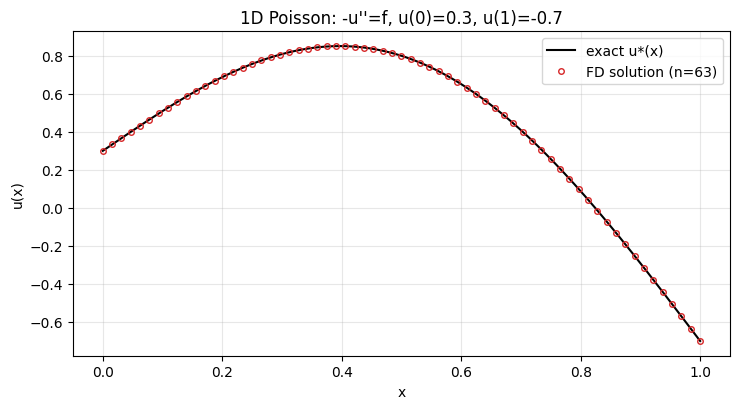

In [2]:
# --- (1) Visualise one solve at n = 63 ---
n = 63
x_all, u_all = poisson_1d(n, f_rhs, alpha, beta)
x_fine = np.linspace(0, 1, 401)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(x_fine, u_star(x_fine), "k-", lw=1.5, label="exact u*(x)")
ax.plot(x_all,  u_all, "o", ms=4, mfc="none", color="tab:red",
        label=f"FD solution (n={n})")
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("1D Poisson: -u''=f, u(0)=0.3, u(1)=-0.7")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [3]:
# --- (2) Convergence study ---
ns = [2**k - 1 for k in range(3, 13)]   # 7, 15, ..., 4095
records = []
for n in ns:
    h = 1.0 / (n + 1)
    x_all, u_all = poisson_1d(n, f_rhs, alpha, beta)
    err = np.max(np.abs(u_all - u_star(x_all)))
    records.append({"n": n, "h": h, "max_err": err})

df = pd.DataFrame(records)

# Empirical rate between consecutive rows: log(err_prev/err_cur)/log(h_prev/h_cur)
rates = [np.nan]
for i in range(1, len(df)):
    r = np.log(df["max_err"].iloc[i-1] / df["max_err"].iloc[i]) / \
        np.log(df["h"].iloc[i-1]      / df["h"].iloc[i])
    rates.append(r)
df["rate"] = rates
df


,n,h,max_err,rate
0,7,1.250e-01,1.295e-02,NaN
1,15,6.250e-02,3.219e-03,2.008e+00
2,31,3.125e-02,8.036e-04,2.002e+00
3,63,1.562e-02,2.008e-04,2.001e+00
4,127,7.812e-03,5.020e-05,2.000e+00
5,255,3.906e-03,1.255e-05,2.000e+00
6,511,1.953e-03,3.137e-06,2.000e+00
7,1023,9.766e-04,7.844e-07,2.000e+00
8,2047,4.883e-04,1.961e-07,2.000e+00
9,4095,2.441e-04,4.903e-08,2.000e+00


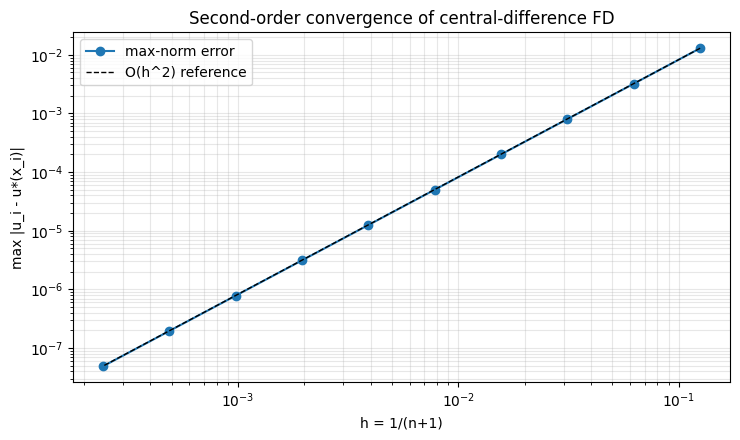

In [4]:
# --- (3) Convergence plot on log-log axes ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.loglog(df["h"], df["max_err"], "o-", label="max-norm error")

# reference h^2 line through the first data point
h0, e0 = df["h"].iloc[0], df["max_err"].iloc[0]
ax.loglog(df["h"], e0 * (df["h"] / h0) ** 2, "k--", lw=1, label="O(h^2) reference")

ax.set_xlabel("h = 1/(n+1)")
ax.set_ylabel("max |u_i - u*(x_i)|")
ax.set_title("Second-order convergence of central-difference FD")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **시각화**. $n = 63$ 만으로도 수치해(점) 가 해석해(검은 곡선) 위에 정확히 얹힌다 —
   $\sin(\pi x)$ 류는 매끄러워 작은 $n$ 으로도 잘 잡힌다.
2. **오차 표 (`rate` 열)**. 연속된 $h$ 사이의 경험적 차수가 **2.0 부근** 으로 거의 일정 —
   이론 $\mathcal{O}(h^2)$ 와 일치한다. 즉 격자를 절반으로 줄이면 오차가 4 배 감소.
3. **로그-로그 그림**. 데이터 점들이 기울기 2 의 직선 위에 정확히 놓인다.
   가장 작은 $h$ (즉 $n \approx 4095$) 부근까지 *반올림오차* 의 흔적은 아직 보이지 않는다 —
   $\kappa(A) \approx 4n^2/\pi^2$ 가 $10^7$ 정도여서, 절단오차 $\sim h^2 \sim 10^{-7}$ 이
   여전히 반올림오차 $\kappa \cdot \varepsilon_{\text{mach}} \sim 10^{-9}$ 보다 크다.
4. **응용 의의**. 1D Poisson 은 PDE 의 *Hello World* 지만, Thomas 가 $n=10^6$ 까지 무리 없이 풀어 준다는 사실은
   더 큰 응용 — 음함수 시간 적분, 1D heat equation, BVP 의 Newton 보정 — 의 *내부 루프* 로서의 의미를 갖는다.

> **결론**: 구조를 살린 솔버 + 2차 차분 = 격자를 두 배로 만들 때마다 오차 1/4. 큰 $n$ 까지 안전하게.

**다음 문제로**: 같은 구조를 *5중대각* 으로 확장한다. 4차 차분 또는 1D 빔의 굽힘 방정식
$u^{(4)}(x) = f$ 에서 자연히 5중대각이 나오는 것을 본다.
